In [90]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# New Good Model

## Libraries

In [91]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder
from src.evaluation.metrics import block_ks_test

from src.models.tf_neural_networks import train_expanding_window_model
from src.data.synthetic import generate_student_t_garch


## MODEL & LOSS FUNCTION

In [92]:
def plot_results(pit_values_test_total, dates_test_total, pred_mu_test_total, pred_sigma_test_total, pred_nu_test_total):
    # Set up the Dashboard
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 6))

    # --- PANEL 2: Out-of-Sample PIT Histogram ---
    axes[0, 0].hist(pit_values_test_total, bins=20, density=True, color="steelblue", edgecolor='black', alpha=0.7)
    axes[0, 0].axhline(y=1.0, color='r', linestyle='--', lw=2, label="Perfect Uniform U(0,1)")
    axes[0, 0].set_title("Out-of-Sample PIT Calibration (Test Set)", fontweight='bold')
    axes[0, 0].set_xlabel("Probability Integral Transform (PIT)")
    axes[0, 0].set_ylabel("Density")
    axes[0, 0].set_ylim(0, 1.5)
    axes[0, 0].legend()

    # --- Plot 2: Parameter Accuracy (Mu) ---
    # A perfect model will align all points on the red dashed 45-degree line
    axes[0, 1].scatter(dates_test_total, pred_mu_test_total, alpha=0.5, color="purple")
    # axes[0, 1].plot([min(true_mu_test), max(true_mu_test)], [min(true_mu_test), max(true_mu_test)], 'r--', lw=2) 
    axes[0, 1].set_title("Parameter Tracking: Mean (μ)", fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel("True Input Mu")
    axes[0, 1].set_ylabel("Network Predicted Mu")

    # --- Plot 3: Parameter Accuracy (Sigma) ---
    axes[1, 0].scatter(dates_test_total, pred_sigma_test_total, alpha=0.5, color="teal")
    # axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
    axes[1, 0].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel("True Input Sigma")
    axes[1, 0].set_ylabel("Network Predicted Sigma")

    # --- Plot 3: Parameter Accuracy (Sigma) ---
    axes[1, 1].scatter(dates_test_total, pred_nu_test_total, alpha=0.5, color="teal")
    # axes[1, 0].plot([min(true_sigma_test), max(true_sigma_test)], [min(true_sigma_test), max(true_sigma_test)], 'r--', lw=2)
    axes[1, 1].set_title("Parameter Tracking: Volatility (σ)", fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel("True Input Sigma")
    axes[1, 1].set_ylabel("Network Predicted Sigma")

    plt.tight_layout()
    plt.show()


## GENERATE TRAIN & TEST DATA (Extrapolating Time)

In [93]:
# # Generate 1500 days of synthetic data
# from datetime import date
# from src.features.features import create_features
# from src.data.synthetic import create_synthetic
# from src.data.data_loader import fetch_asset_data
# # 
# start_date = date(2015, 12, 31)
# end_date = date(2025, 12, 31)

# # Assuming you already have a VIX series loaded:
# # df_vix = fetch_asset_data('^VIX', ...)
# df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
# # df_vix = (df_vix[['prices']]) / np.sqrt(252)
# # df_vix.columns = ['VIX']
# vix_series = df_vix[['prices']]
# # 1. Linear Dependence (sigma scales directly with VIX)
# df_prices, df_vix = create_synthetic(
#     type='vix_dependent', 
#     vix_series=vix_series, 
#     dynamics='sinusoidal'
# )

# # # df_synth_prices, df_synth_vix = generate_student_t_garch(n_days=2000, nu=30)

# # df_prices, df_vix = create_synthetic(
# #     type='time_varying_normal', 
# #     dynamics='sinusoidal', #linear
# #     n_days=2000
# # )

# # Create features exactly as we do for real data
# window_size = 22 * 6

# df_features = create_features(df_prices, df_vix, window_size, n_lags=2)
# df_features.dropna(inplace=True)
# df_features = df_features.astype('float32')

# df_y = df_features['returns']
# df_X = df_features.drop(columns=['returns'])

# df_prices['returns'].plot(title='Synthetic Returns (AR1-GARCH1,1 Student-T)', figsize=(12, 4))


In [94]:
from datetime import date
from src.data.data_loader import fetch_asset_data
from src.features.features import create_features
from src.models.baselines import rolling_vix_scaled_student_t

start_date = date(2010, 12, 31)
# start_date = date(2020, 12, 31)
end_date = date(2025, 12, 31)

ticker = 'ARKK'
ticker = 'USO'
ticker = 'USDCLP=X'
ticker = 'BTC-USD'
# ticker = 'GOOG'
# ticker = 'AAPL'
ticker = 'SQM-B.SN'

ticker = 'VAPORES.SN'

tickers = [ticker]

In [95]:
df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
df_vix = (df_vix[['prices']]) / np.sqrt(252)
df_vix.columns = ['VIX']
df_vix.head()

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


,VIX
Date,
2010-12-31,1.118145
2011-01-03,1.109326
2011-01-04,1.094837
2011-01-05,1.072159
2011-01-06,1.096097


In [98]:
def feature_engineering(df, df_vix):
    window_size = 22 * 6
    df_features = create_features(df, df_vix, window_size, n_lags=3)
    # df_features = pd.concat([df_features, df[['volume_ret']]], axis=1)

    window_size = int(22 / 2)
    df_features_st = create_features(df, df_vix, window_size, n_lags=1)
    df_features_st.dropna(inplace=True)
    df_features_st = df_features_st.astype('float32')
    df_features_st = df_features_st[['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew']]
    df_features_st.columns = ['ret_1_mean_st', 'ret_1_std_st', 'ret_1_kurt_st', 'ret_1_skew_st']

    df_features = pd.concat([df_features, df_features_st], axis=1)

    df_features.dropna(inplace=True)
    df_features = df_features.astype('float32')
    return df_features


In [99]:

for i, ticker in enumerate(tickers):
    print(f"Processing {ticker}...")
    
    # 1. Fetch Data
    df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])
    df_features = feature_engineering(df, df_vix)
    print(df_features.head())
    # 2. Run Both Models
    window_size = 22 * 6
    pred_vix_student = rolling_vix_scaled_student_t(df_features['returns'], df_features['VIX'], window=window_size)
    
    break
    # 3. Evaluate to get the PIT series
    eval_start = window_size + 1
    actuals = df_ret['returns'][eval_start:]
    eval_vix_student = evaluate_forecasts(actuals, pred_vix_student[eval_start:])
    
     # 5. Calculate Block KS Failure Ratios
    fail_vix_student = get_failure_ratio(eval_vix_student['PIT'], block=block_size)

    df_results_ratio.loc[ticker, 'vix_student'] = fail_vix_student

    results_models[ticker]['vix_student'] = eval_vix_student


Processing VAPORES.SN...
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
             returns       VIX     ret_1     ret_2     ret_3  ret_1_mean  \
Date                                                                       
2011-07-08  1.667384  1.004755 -0.554080 -2.387303 -1.934679   -0.497668   
2011-07-11  2.193605  1.004755  1.667384 -0.554080 -2.387303   -0.491556   
2011-07-12 -0.353503  1.158461  2.193605  1.667384 -0.554080   -0.471757   
2011-07-13 -1.245423  1.251692 -0.353503  2.193605  1.667384   -0.469283   
2011-07-14  0.820261  1.254212 -1.245423 -0.353503  2.193605   -0.464325   

            ret_1_std  ret_1_kurt  ret_1_skew  ret_1_mean_st  ret_1_std_st  \
Date                                                                         
2011-07-08   3.779032   20.980919    2.929914      -0.296172      1.296266   
2011-07-11   3.781897   20.889370    2.919432      -0.110386      1.423816   
2011-07-12   3.789109   20.647045    2.889635     

In [ ]:
stop

In [ ]:

df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=['volume'])
# df = fetch_asset_data(ticker=ticker, start=start_date, end=end_date, features=[])

if ticker == 'USDCLP=X':
    df.loc[df.prices < 200, 'prices'] = 680

df_vix = fetch_asset_data(ticker='^VIX', start=start_date, end=end_date, features=[])
df_vix = (df_vix[['prices']]) / np.sqrt(252)
df_vix.columns = ['VIX']

window_size = 22 * 6
df_features = create_features(df, df_vix, window_size, n_lags=3)
df_features = pd.concat([df_features, df[['volume_ret']]], axis=1)

window_size = int(22 / 2)
df_features_st = create_features(df, df_vix, window_size, n_lags=1)
df_features_st.dropna(inplace=True)
df_features_st = df_features_st.astype('float32')
df_features_st = df_features_st[['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew']]
df_features_st.columns = ['ret_1_mean_st', 'ret_1_std_st', 'ret_1_kurt_st', 'ret_1_skew_st']

df_features = pd.concat([df_features, df_features_st], axis=1)

df_features.dropna(inplace=True)
df_features = df_features.astype('float32')

# df_y = df_features['returns']
# df_X = df_features.drop(columns=['returns'])


Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [ ]:
df_features.columns

Index(['returns', 'VIX', 'ret_1', 'ret_2', 'ret_3', 'ret_1_mean', 'ret_1_std',
       'ret_1_kurt', 'ret_1_skew', 'volume_ret', 'ret_1_mean_st',
       'ret_1_std_st', 'ret_1_kurt_st', 'ret_1_skew_st'],
      dtype='object')

In [ ]:
# max_volume = float(df_features['volume_ret'].describe([0.01, 0.99])['99%'])
# min_volume = float(df_features['volume_ret'].describe([0.01, 0.99])['1%'])
# df_features.loc[df_features['volume_ret'] > max_volume, 'volume_ret'] = max_volume
# df_features.loc[df_features['volume_ret'] < min_volume, 'volume_ret'] = min_volume
# df_features['volume_ret'].plot()

# df_features['volume_ret'].describe([0.01, 0.99])['99%']

In [ ]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
# model = WideAndDeepStudentTNet()

columns_linear = ['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew', 'ret_1_mean_st', 'ret_1_std_st',  'ret_1_kurt_st', 'ret_1_skew_st', 'VIX', 'ret_1', 'ret_2', 'ret_3']
columns_linear = ['ret_1_mean', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew', 'ret_1_mean_st', 'ret_1_std_st', 'VIX']

# columns_linear = ['ret_1_mean', 'ret_1_std', 'ret_1_mean_st', 'ret_1_std_st', 'ret_1_kurt', 'ret_1_skew', 'VIX']
columns_deep = ['VIX', 'ret_1', 'ret_2', 'ret_3']
# columns_deep = ['VIX', 'volume_ret', 'ret_1', 'ret_2', 'ret_3' ]
# columns_deep = ['VIX', 'volume_ret']


df_X_linear = df_features[columns_linear]
df_X_deep = df_features[columns_deep]
df_y = df_features['returns']

# # 1. Build the Wide/Linear Tensor (Contains 2 features)
# X_linear_np = np.hstack([feat_momentum, feat_realized_vol])
# X_linear_train = tf.convert_to_tensor(X_linear_np, dtype=tf.float32)

# # 2. Build the Deep/Non-Linear Tensor (Contains 2 features)
# X_deep_np = np.hstack([feat_vix, feat_rsi])
# X_deep_train = tf.convert_to_tensor(X_deep_np, dtype=tf.float32)

# # Target variable
# y_train = tf.convert_to_tensor(np.random.normal(0, 0.02, (N_DAYS, 1)), dtype=tf.float32)

# df_features.columns


In [ ]:
porcentage_train = 0.6
n_train = int(porcentage_train * len(df_X_linear))
test_window = 22 * 1
epochs = 501

# Call the refactored expanding window training function
dates_test_total, pred_mu_test_total, pred_sigma_test_total, pred_nu_test_total, pit_values_test_total = train_expanding_window_model(
    df_X_linear=df_X_linear, 
    # df_X_deep=df_X_deep, 
    # df_X_deep=None, 
    df_y=df_y, 
    model_class='Linear', 
    # model_class='WideAndDeep', 
    epochs=epochs, 
    test_window=test_window, 
    porcentage_train=porcentage_train,
    lr=0.015
)


Training Linear Network on Polynomial Data...
------------------------------
Train size: 2160, Total data: 3601, Epochs: 501 (Cold Start)
------------------------------
Epoch 000 | NLL Loss: 25.6980
Epoch 100 | NLL Loss: 2.2210
Epoch 200 | NLL Loss: 2.1497
Epoch 300 | NLL Loss: 2.1164
Epoch 400 | NLL Loss: 2.0993
Epoch 500 | NLL Loss: 2.0888
------------------------------
Train size: 2182, Total data: 3601, Epochs: 250 (Warm Start)
------------------------------
Epoch 000 | NLL Loss: 2.1035
Epoch 100 | NLL Loss: 2.0946
Epoch 200 | NLL Loss: 2.0867
Epoch 249 | NLL Loss: 2.0832
------------------------------
Train size: 2204, Total data: 3601, Epochs: 250 (Warm Start)
------------------------------
Epoch 000 | NLL Loss: 2.0870
Epoch 100 | NLL Loss: 2.0792
Epoch 200 | NLL Loss: 2.0742
Epoch 249 | NLL Loss: 2.0725
------------------------------
Train size: 2226, Total data: 3601, Epochs: 250 (Warm Start)
------------------------------
Epoch 000 | NLL Loss: 2.0743
Epoch 100 | NLL Loss: 2.07

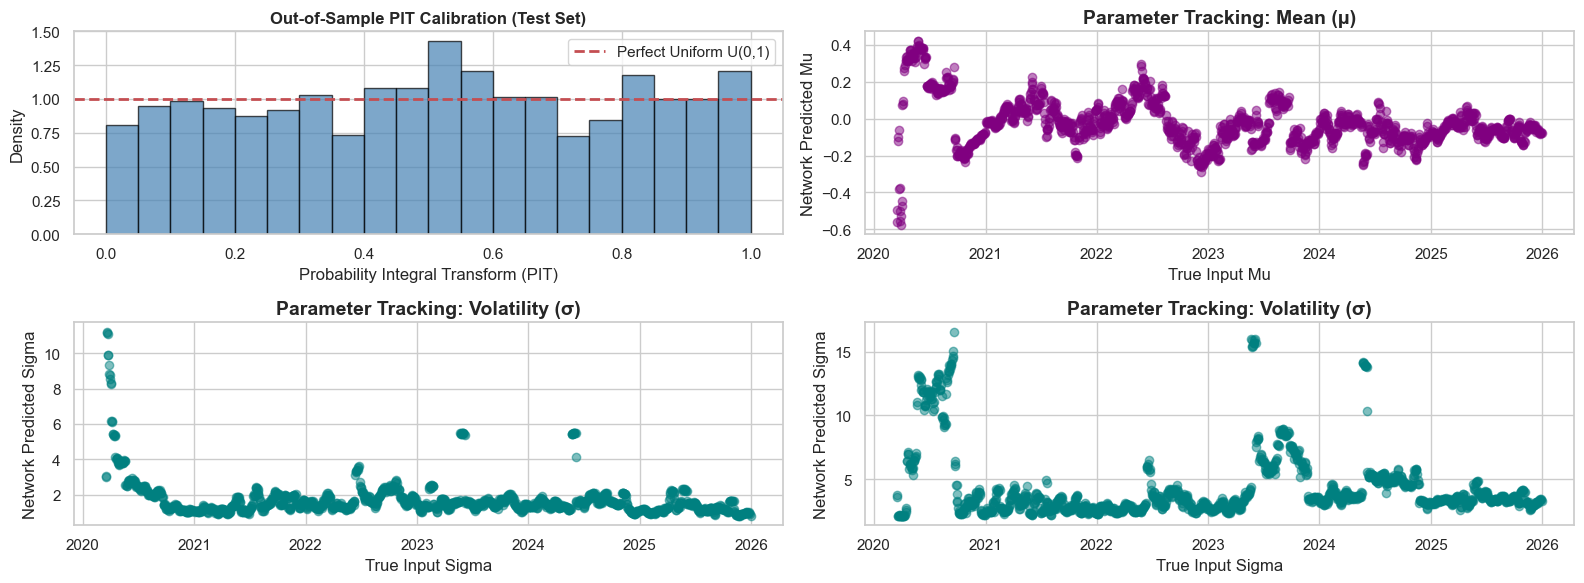


--- INDEPENDENT BLOCK TEST SUMMARY (1441-Day Windows) ---
Total Independent Blocks: 1
Blocks Failed (p < 0.05): 1
True Failure Rate:        100.0%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2020-03-17,2025-12-30,0.039087,0.023827,❌ FAILED


In [ ]:

plot_results(pit_values_test_total, dates_test_total, pred_mu_test_total, pred_sigma_test_total, pred_nu_test_total)
df_pit_values_test = pd.DataFrame(pit_values_test_total, index=dates_test_total, columns=['PIT'])
block_ks_test(df_pit_values_test['PIT'], block_size=len(df_pit_values_test))


In [ ]:
block_ks_test(df_pit_values_test['PIT'], block_size=22 * 6)


--- INDEPENDENT BLOCK TEST SUMMARY (132-Day Windows) ---
Total Independent Blocks: 11
Blocks Failed (p < 0.05): 3
True Failure Rate:        27.3%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2020-03-17,2020-09-24,0.126750,0.026224,❌ FAILED
1,2020-09-25,2021-04-06,0.161083,0.001848,❌ FAILED
2,2021-04-07,2021-10-15,0.074988,0.427144,✅ PASSED
3,2021-10-18,2022-04-25,0.119296,0.042879,❌ FAILED
4,2022-04-26,2022-11-07,0.113959,0.059863,✅ PASSED
5,2022-11-08,2023-05-16,0.069919,0.516151,✅ PASSED
6,2023-05-17,2023-11-28,0.074660,0.432643,✅ PASSED
7,2023-11-29,2024-06-07,0.100181,0.131980,✅ PASSED
8,2024-06-10,2024-12-20,0.047259,0.916023,✅ PASSED
9,2024-12-23,2025-07-03,0.057227,0.758280,✅ PASSED


1% VaR: 2.43%
5% VaR: 9.92%


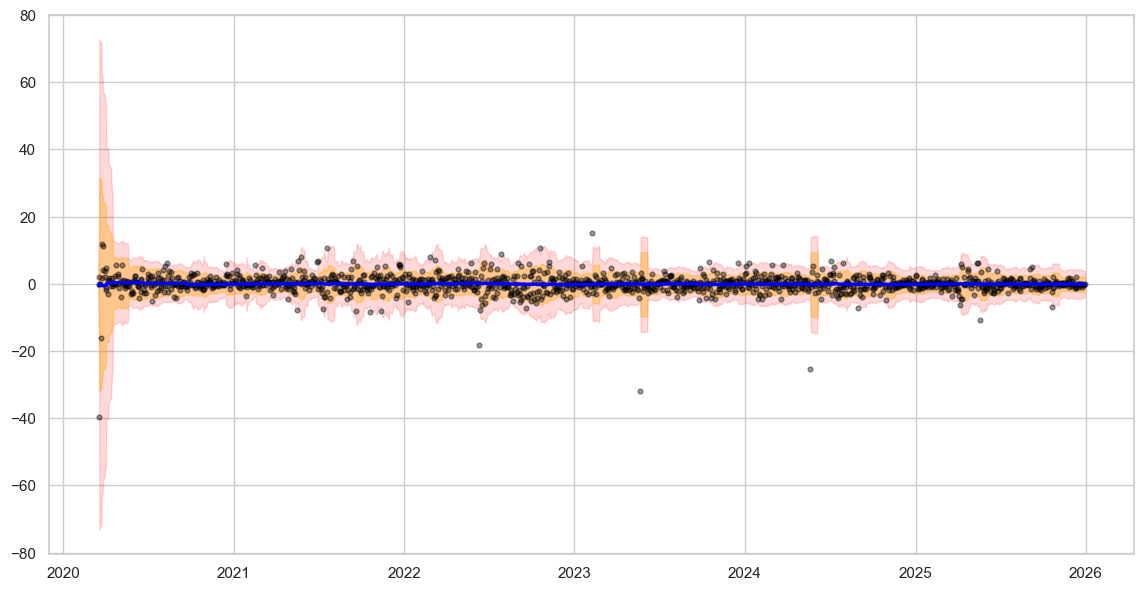

In [ ]:

# 3. Create the distribution with the flattened parameters
test_dist = tfd.StudentT(
    df=pred_nu_test_total, 
    loc=pred_mu_test_total, 
    scale=pred_sigma_test_total
)

n_train = int(porcentage_train * len(df_X_linear))
df_y_test = df_y.iloc[n_train:]
y_test = tf.convert_to_tensor(np.matrix(df_y_test))
y_test_flat = tf.reshape(y_test, [-1])

q_01 = test_dist.quantile(0.01).numpy()
q_05 = test_dist.quantile(0.05).numpy()
q_95 = test_dist.quantile(0.95).numpy()
q_99 = test_dist.quantile(0.99).numpy()

df_results = pd.DataFrame({
    'Date': dates_test_total,
    'Actual Returns': y_test_flat.numpy(),
    'Predicted Mu': pred_mu_test_total,
    'Q_01': q_01,
    'Q_05': q_05,
    'Q_95': q_95,
    'Q_99': q_99
})
df_results.set_index('Date', inplace=True)
df_results['between_01_99'] = ((df_results['Actual Returns'] >= df_results['Q_01']) & (df_results['Actual Returns'] <= df_results['Q_99']))
df_results['between_05_95'] = ((df_results['Actual Returns'] >= df_results['Q_05']) & (df_results['Actual Returns'] <= df_results['Q_95']))

print(f"1% VaR: {1 - df_results['between_01_99'].sum() / len(df_results):.2%}")
print(f"5% VaR: {1 - df_results['between_05_95'].sum() / len(df_results):.2%}")

# 3. Set up the plot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# --- PLOT THE RISK BANDS ---
# Plot the 1% to 99% Extreme Tail Risk interval (Light Red)
plt.fill_between(
    dates_test_total, q_01, q_99, 
    color='red', alpha=0.15, 
    label='1% - 99% Extreme Risk Band'
)

# Plot the 5% to 95% Standard Risk interval (Orange)
plt.fill_between(
    dates_test_total, q_05, q_95, 
    color='orange', alpha=0.35, 
    label='5% - 95% Standard Risk Band'
)

# --- PLOT THE DATA & MEAN ---
# Plot the raw, noisy market data
plt.scatter(
    dates_test_total, y_test_flat, 
    color='black', s=12, alpha=0.4, 
    label='Actual Market Returns'
)

# Plot the predicted center (Mu)
plt.plot(
    dates_test_total, pred_mu_test_total, 
    color='blue', lw=2.5, 
    label='Predicted Mean ($\mu_t$)'
)



In [ ]:
stop

NameError: name 'stop' is not defined

## 4. Synthetic Data Generation
Let's test our models on synthetic data (AR(1)-GARCH(1,1) with Student-t innovations) to see how they perform when we know the true distribution has heavy tails and volatility clustering.

<Axes: title={'center': 'Synthetic Returns (AR1-GARCH1,1 Student-T)'}, xlabel='Date'>

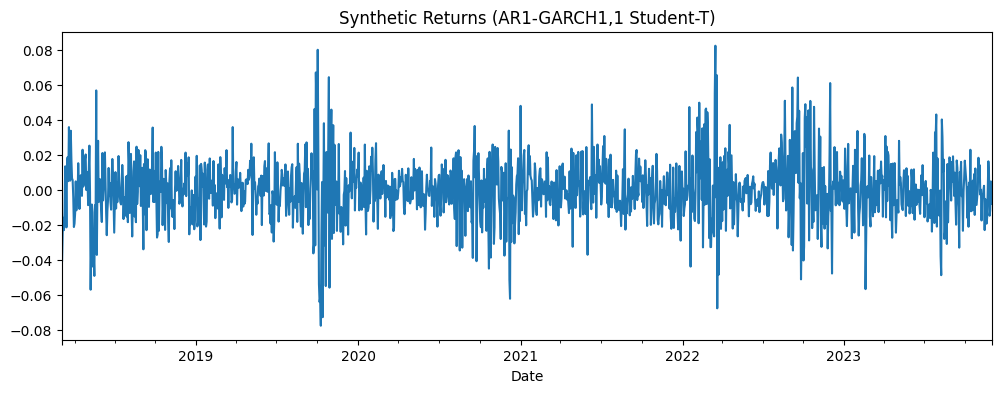

In [ ]:
from src.data.synthetic import generate_student_t_garch
from src.features.features import create_features

# Generate 1500 days of synthetic data
df_synth_prices, df_synth_vix = generate_student_t_garch(n_days=1500, nu=30)

# Create features exactly as we do for real data
window_size = 22 * 6
df_synth_features = create_features(df_synth_prices, df_synth_vix, window_size, n_lags=2)
df_synth_features.dropna(inplace=True)
df_synth_features = df_synth_features.astype('float32')

df_synth_y = df_synth_features['returns']
df_synth_X = df_synth_features.drop(columns=['returns'])

df_synth_prices['returns'].plot(title='Synthetic Returns (AR1-GARCH1,1 Student-T)', figsize=(12, 4))


## 5. Hyperparameter Tuning and Model Selection
Using `optuna` to search for the best model configuration. We evaluate models based on their probabilistic calibration (Block K-S Test on PIT) and their sharpness (CRPS).

In [ ]:
from src.evaluation.tuning import hyperparameter_search

# Run a quick search on the synthetic data
print("Starting Optuna Hyperparameter Search...")
df_results = hyperparameter_search(
    df_X=df_synth_X,
    df_y=df_synth_y,
    n_trials=5,  # Keep it small for demonstration
    test_window=22 * 1,
    porcentage_train=0.8
)

display(df_results)
print("Best Configuration found:")
print(df_results.iloc[0])


Starting Optuna Hyperparameter Search...
Training WideAndDeep Network on Polynomial Data...
------------------------------
Train size: 1094, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.4224
------------------------------
Train size: 1116, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.4830
------------------------------
Train size: 1138, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.4382
------------------------------
Train size: 1160, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.4330
------------------------------
Train size: 1182, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.4193
------------------------------
Train size: 1204, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.3825
------------------------------
Train size: 1226, Total data: 1368
------------------------------
Epoch 000 | NLL Loss: 32.4301
-------------------

,model_class,lr,epochs,crps,log_likelihood,ks_fail_rate,objective_val
4,Linear,0.017448,100,0.973994,-2.105337,0.75,4.723994
2,Linear,0.002827,50,0.931308,-2.361442,1.00,5.931308
0,WideAndDeep,0.000769,50,0.932128,-2.567386,1.00,5.932128
3,Linear,0.000638,150,0.979861,-3.403991,1.00,5.979861
1,Linear,0.000186,100,1.099025,-9.879476,1.00,6.099025


Best Configuration found:
model_class         Linear
lr                0.017448
epochs                 100
crps              0.973994
log_likelihood   -2.105337
ks_fail_rate          0.75
objective_val     4.723994
Name: 4, dtype: object


## 6. Baselines Comparison
Let's compare our best neural network to simple historical baselines (Normal and Student-T).

In [ ]:
from src.evaluation.tuning import evaluate_model_config

# Baseline: Historical Normal
config_normal = {'model_class': 'Historical_Normal'}
crps_n, ll_n, ks_fail_n = evaluate_model_config(df_synth_X, df_synth_y, config_normal, test_window=22, porcentage_train=0.8)

# Baseline: Historical Student-T
config_t = {'model_class': 'Historical_StudentT'}
crps_t, ll_t, ks_fail_t = evaluate_model_config(df_synth_X, df_synth_y, config_t, test_window=22, porcentage_train=0.8)

print(f"Historical Normal   -> CRPS: {crps_n:.4f}, KS Fail Rate: {ks_fail_n:.1%}")
print(f"Historical StudentT -> CRPS: {crps_t:.4f}, KS Fail Rate: {ks_fail_t:.1%}")



--- INDEPENDENT BLOCK TEST SUMMARY (60-Day Windows) ---
Total Independent Blocks: 4
Blocks Failed (p < 0.05): 1
True Failure Rate:        25.0%

--- INDEPENDENT BLOCK TEST SUMMARY (60-Day Windows) ---
Total Independent Blocks: 4
Blocks Failed (p < 0.05): 1
True Failure Rate:        25.0%
Historical Normal   -> CRPS: 0.8704, KS Fail Rate: 25.0%
Historical StudentT -> CRPS: 0.8696, KS Fail Rate: 25.0%
